In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sales_data = pd.read_csv("Sales Data.csv")
sales_data.head()

,Unnamed: 0,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour,Unnamed: 11,Unnamed: 12
0,1,295665,Macbook Pro Laptop,1,1700.00,"Monday, December 30, 2019","136 Church St, New York City, NY 10001",12,1700.00,New York City,0,NaN,NaN
1,2,295666,LG Washing Machine,1,600.00,"Sunday, December 29, 2019","562 2nd St, New York City, NY 10001",12,600.00,New York City,7,NaN,NaN
2,3,295667,USB-C Charging Cable,1,11.95,"Thursday, December 12, 2019","277 Main St, New York City, NY 10001",12,11.95,New York City,18,NaN,NaN
3,4,295668,27in FHD Monitor,1,149.99,"Sunday, December 22, 2019","410 6th St, San Francisco, CA 94016",12,149.99,San Francisco,15,NaN,NaN
4,5,295669,USB-C Charging Cable,1,11.95,"Wednesday, December 18, 2019","43 Hill St, Atlanta, GA 30301",12,11.95,Atlanta,12,NaN,NaN


In [4]:
sales_data.isnull().sum()
sales_data.columns
sales_data = sales_data.drop(columns=['Unnamed: 11','Unnamed: 12'])

In [6]:
#Converting Order Date
sales_data['Order Date'] = pd.to_datetime(sales_data['Order Date'])

In [8]:
#1. Create New Month Column Showing Exact Month Names
sales_data['Month Name'] = sales_data['Order Date'].dt.month_name()

sales_data[['Order Date','Month Name']].head()

,Order Date,Month Name
0,2019-12-30,December
1,2019-12-29,December
2,2019-12-12,December
3,2019-12-22,December
4,2019-12-18,December


City
San Francisco    8262203.91
Los Angeles      5452570.80
New York City    4664317.43
Boston           3661642.01
Atlanta          2795498.58
Dallas           2767975.40
Seattle          2747755.48
Portland         2320490.61
Austin           1819581.75
Name: Sales, dtype: float64


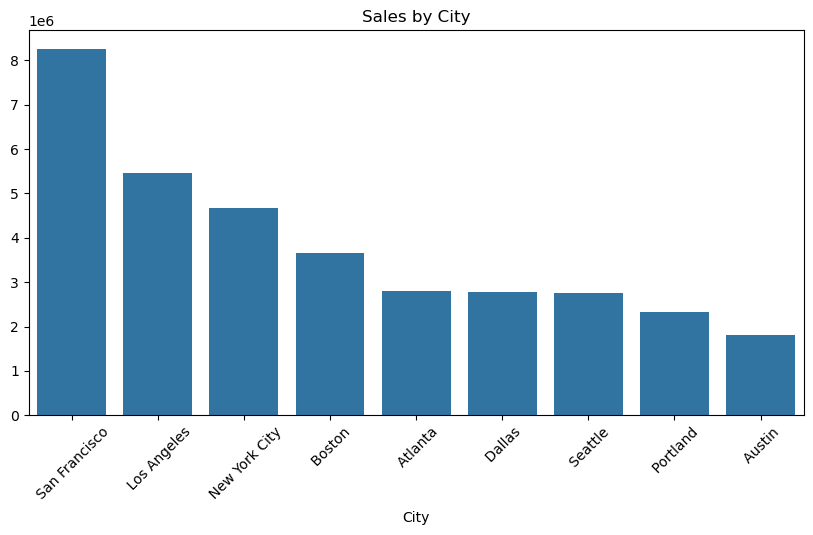

In [10]:
#City with highest sales
city_sales = sales_data.groupby('City')['Sales'].sum().sort_values(ascending=False)
print(city_sales)

plt.figure(figsize=(10,5))
sns.barplot(
    x=city_sales.index,
    y=city_sales.values
)

plt.xticks(rotation=45)
plt.title('Sales by City')
plt.show()

Product
Macbook Pro Laptop        8037600.00
iPhone                    4794300.00
ThinkPad Laptop           4129958.70
Google Phone              3319200.00
27in 4K Gaming Monitor    2435097.56
Name: Sales, dtype: float64


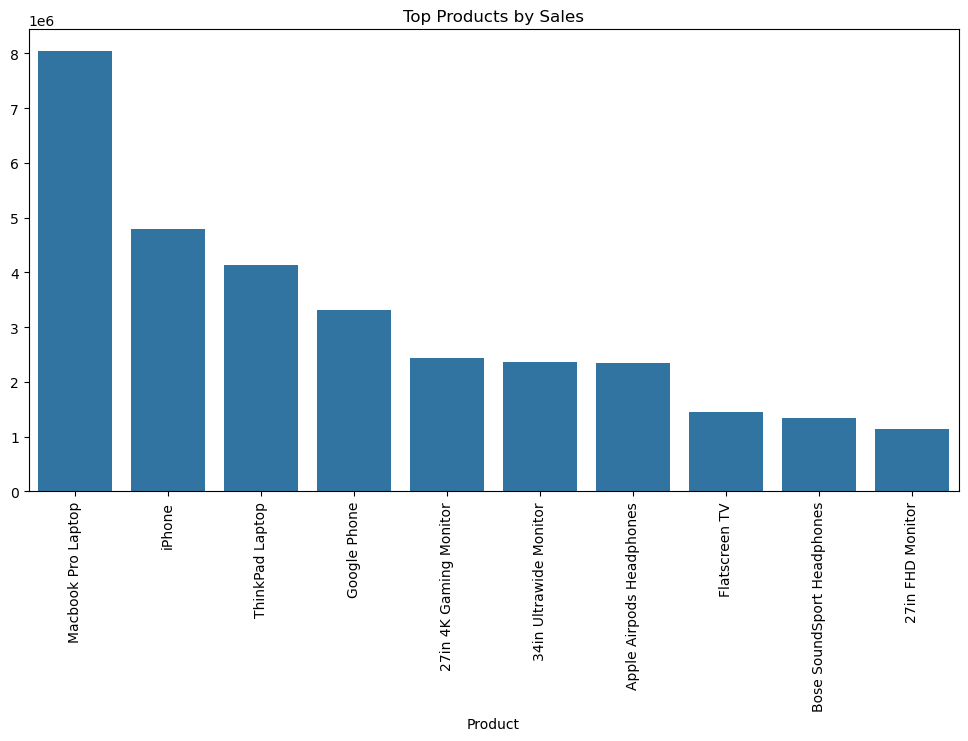

In [28]:
#Product with highest sales
product_sales = sales_data.groupby('Product')['Sales'].sum().sort_values(ascending=False)
print(product_sales.head())

plt.figure(figsize=(12,6))
sns.barplot(
    x=product_sales.index[:10],
    y=product_sales.values[:10]
)

plt.xticks(rotation=90)
plt.title('Top Products by Sales')
plt.show()

In [14]:
#Separate Order Date into Day, Month and Year
sales_data['Day'] = sales_data['Order Date'].dt.day

sales_data['Month'] = sales_data['Order Date'].dt.month

sales_data['Year'] = sales_data['Order Date'].dt.year

sales_data[['Order Date','Day','Month','Year']].head()

,Order Date,Day,Month,Year
0,2019-12-30,30,12,2019
1,2019-12-29,29,12,2019
2,2019-12-12,12,12,2019
3,2019-12-22,22,12,2019
4,2019-12-18,18,12,2019


Year
2019    34483365.68
2020        8670.29
Name: Sales, dtype: float64


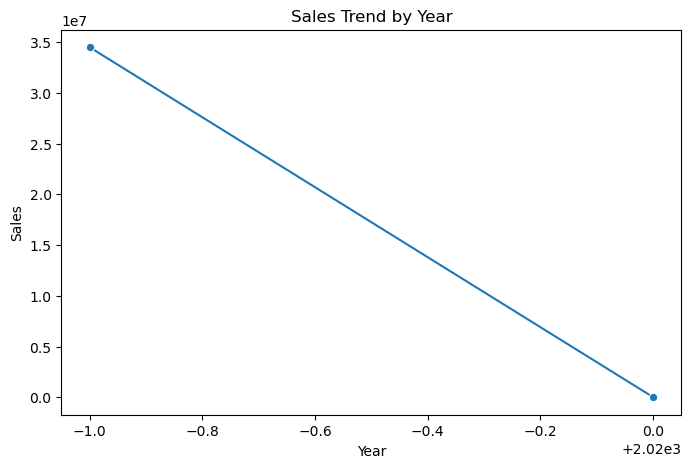

In [17]:
#Sales Trend for Different Years
year_sales = sales_data.groupby('Year')['Sales'].sum()
print(year_sales)

plt.figure(figsize=(8,5))

sns.lineplot(
    x=year_sales.index,
    y=year_sales.values,
    marker='o'
)

plt.title("Sales Trend by Year")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.show()

Weekday
Friday       4855938.38
Monday       4883326.72
Saturday     4904357.01
Sunday       4932169.66
Thursday     4839465.16
Tuesday      5087956.78
Wednesday    4988822.26
Name: Sales, dtype: float64


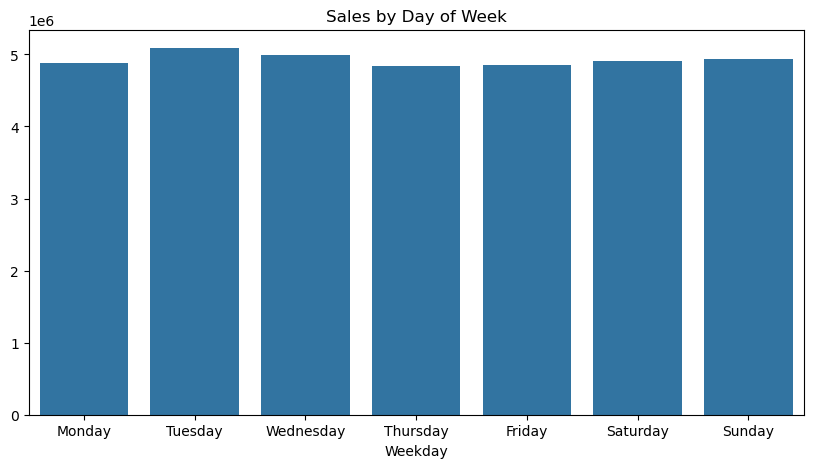

In [19]:
#Which Day of the Week Recorded Highest Sales?
sales_data['Weekday'] = sales_data['Order Date'].dt.day_name()
weekday_sales = sales_data.groupby('Weekday')['Sales'].sum()

print(weekday_sales)

order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

plt.figure(figsize=(10,5))

sns.barplot(
    x=weekday_sales.index,
    y=weekday_sales.values,
    order=order
)

plt.title("Sales by Day of Week")
plt.show()

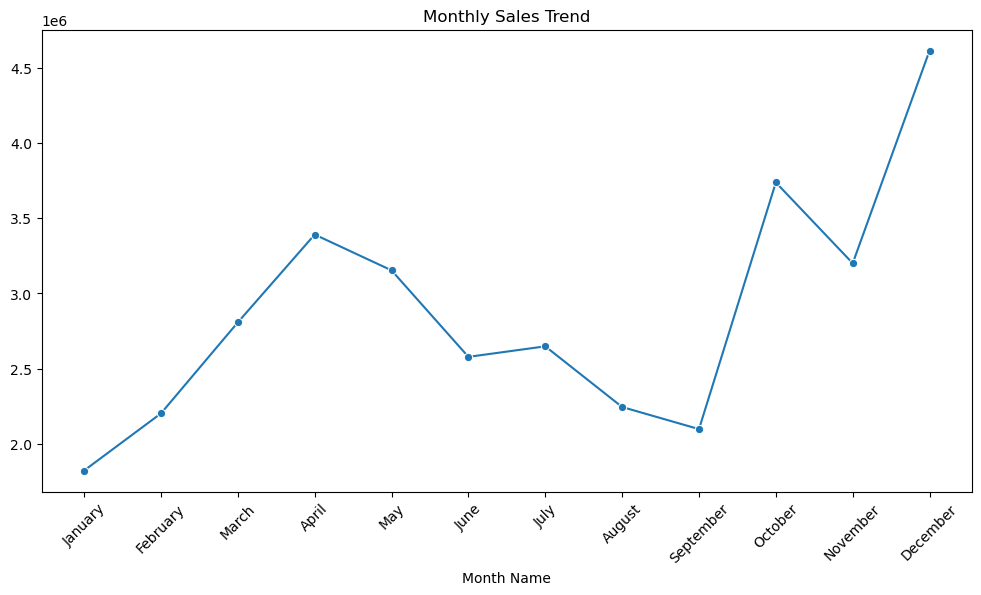

In [21]:
#Which month record highest sales ?
month_sales = sales_data.groupby('Month Name')['Sales'].sum()
month_order = [
'January',
'February',
'March',
'April',
'May',
'June',
'July',
'August',
'September',
'October',
'November',
'December'
]

month_sales = month_sales.reindex(month_order)

plt.figure(figsize=(12,6))

sns.lineplot(
    x=month_sales.index,
    y=month_sales.values,
    marker='o'
)

plt.xticks(rotation=45)

plt.title("Monthly Sales Trend")

plt.show()

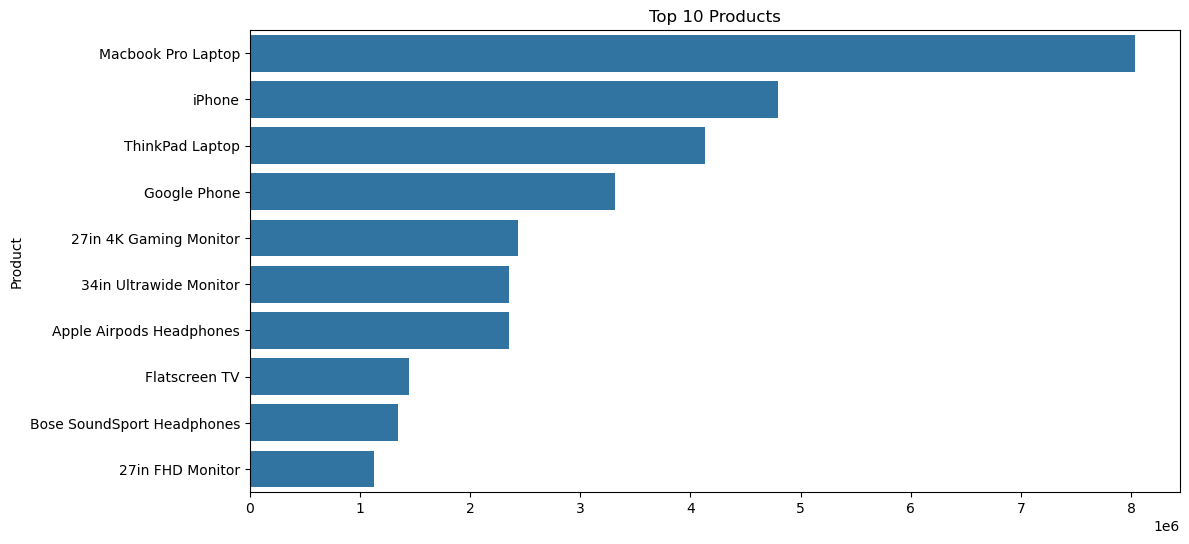

In [23]:
#Top 10 Products
top10 = product_sales.head(10)
plt.figure(figsize=(12,6))

sns.barplot(
    x=top10.values,
    y=top10.index
)

plt.title("Top 10 Products")

plt.show()

In [3]:
sales_data.to_csv("Sales_Cleaned.csv", index=False)